In [1]:
import os
from pathlib import Path

import geomulticorr as gmc

import xdem

import matplotlib.pyplot as plt

geomulticorr 0.1.0


# 1. Open `Session` for data manipulation

In [2]:
session = gmc.open_gmc_session("/data/risques/cusicand/GMC_Projects/GMC_TEST", epsg_code=2154)

[ GMC ✓ ] : GMC project structure found


[ GMC 🚀 ] : Session 'GMC_TEST' initialized.


In [3]:
raster_bank = session.map_georasters_bank("/data/risques/cusicand/GMC_REPOSITORY/french_alps")

[ GMC 🔍 ] : Mapping georasters
|████████████████████████████████████████| 43/43 [100%] in 1:07.2 (0.57/s)      


In [4]:
raster_bank

,filename,sensor,xRes,yRes,bands,rows,cols,acq_date,file_path,sensor_family,sensor_platform,acq_datetime,src_crs,geometry
0,20210710_102538_96_2416_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2021-07-10,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2021-07-10 10:25:38,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
1,20220722_095155_71_2233_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2022-07-22,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2022-07-22 09:51:55,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
2,20190713_102109_43_105c_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2019-07-13,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2019-07-13 10:21:09,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
3,PSScene_20240823_103453_07_24bd_3B_AnalyticMS_...,planetscope,3.0,3.0,4,1139,1393,2024-08-23,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2024-08-23 10:34:53,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."
4,20250716_105532_47_252e_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2025-07-16,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2025-07-16 10:55:32,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
5,20180729_095421_1040_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2018-07-29,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
6,20160816_093503_0e0f_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2016-08-16,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
7,20200725_103349_66_1066_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2020-07-25,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2020-07-25 10:33:49,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
8,PSScene_20210826_093758_94_2439_3B_AnalyticMS_...,planetscope,3.0,3.0,4,1139,1393,2021-08-26,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2021-08-26 09:37:58,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."
9,PSScene_20170801_094239_0f15_3B_AnalyticMS_SR_...,planetscope,3.0,3.0,4,1139,1393,2017-08-01,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2017-08-01 09:42:39,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."


In [3]:
raster_bank = session.get_georasters_map()

<Axes: >

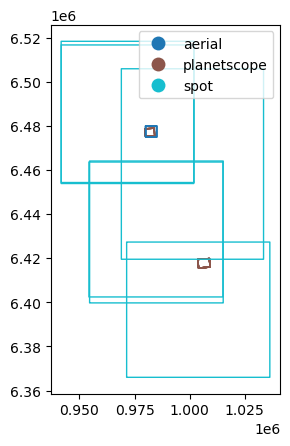

In [4]:
raster_bank.plot(
    column="sensor_family",
    categorical=True,
    facecolor="none",
    legend=True,
)

In [5]:
selected_rasters = raster_bank[
    raster_bank["sensor_family"].isin(["planetscope"])
]

In [6]:
selected_rasters

,filename,sensor,xRes,yRes,bands,rows,cols,acq_date,file_path,sensor_family,sensor_platform,acq_datetime,src_crs,geometry
0,20210710_102538_96_2416_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2021-07-10,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2021-07-10 10:25:38,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
1,20220722_095155_71_2233_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2022-07-22,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2022-07-22 09:51:55,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
2,20190713_102109_43_105c_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2019-07-13,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2019-07-13 10:21:09,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
3,PSScene_20240823_103453_07_24bd_3B_AnalyticMS_...,planetscope,3.0,3.0,4,1139,1393,2024-08-23,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2024-08-23 10:34:53,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."
4,20250716_105532_47_252e_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2025-07-16,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2025-07-16 10:55:32,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
5,20180729_095421_1040_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2018-07-29,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
6,20160816_093503_0e0f_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2016-08-16,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
7,20200725_103349_66_1066_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2020-07-25,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2020-07-25 10:33:49,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
8,PSScene_20210826_093758_94_2439_3B_AnalyticMS_...,planetscope,3.0,3.0,4,1139,1393,2021-08-26,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2021-08-26 09:37:58,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."
9,PSScene_20170801_094239_0f15_3B_AnalyticMS_SR_...,planetscope,3.0,3.0,4,1139,1393,2017-08-01,/data/risques/cusicand/GMC_REPOSITORY/french_a...,planetscope,planetscope,2017-08-01 09:42:39,EPSG:32632,"POLYGON ((979960.261 6475289.636, 979960.21 64..."


# 2. Drawing `PZONE` manually or in QGIS

## 2.1. Option A — draw interactively on a map:

In [8]:
# Draw your polygon on the map, then run the next cell:
get_gdf = session.draw_polygon_manually(raster_bank=raster_bank)

Map(center=[46.8, 8.2], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_…

Draw your polygon(s) on the map above. When done, run the next cell to get the GeoDataFrame.


In [9]:
aoi = get_gdf()
session.insert_pzone(aoi.geometry.iloc[0], pz_name="PasDeLours", pz_shortname="PDL")

[ GMC ✓ ] : Pzone 'PasDeLours' inserted.


In [7]:
session.get_pzones_overview()

,pz_name,pz_shortname,pz_surf,geometry
0,PasDeLours,PDL,None,"POLYGON ((1004034.017 6415940.841, 1003869.381..."


## 2.2. Option B — load from a vector file:

In [11]:
# TODO: add aoi to the session, from external dawn.

# 3. Crop data using `PZONE` extent

In [12]:
session.sieve_bulk(selected_rasters,
                   target_resolution=3)

[ GMC 📋 ] : Map epsg : EPSG:2154
Pzone epsg : EPSG:2154
[ GMC 📋 ] : Target resolution: 3 (EPSG:2154)
[ GMC 📋 ] : Pzone: PasDeLours
[ GMC 📋 ] : Intersecting rasters: 22
Cropping PasDeLours_2016-08-16_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2016-08-16_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2016-08-16_planetscope.tif
Cropping PasDeLours_2017-07-03_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2017-07-03_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-03_planetscope.tif
Cropping PasDeLours_2017-07-13_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2017-07-13_planetscope.tif


...

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2024-07-08_planetscope.tif
Cropping PasDeLours_2025-07-16_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2025-07-16_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2025-07-16_planetscope.tif


{'PasDeLours': [PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2016-08-16_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-03_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-13_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2018-07-29_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2019-07-13_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2020-07-25_planetscope.tif'),
  PosixPath('/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2021-07-10_planetscope.tif'),
  Posi

# 4. Register `Thumbs`

In [8]:
session.update_thumbs()
session.get_thumbs_overview()  # check

/home/cusicand/GeoMultiCorr/geomulticorr/core/session.py:722: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated = pd.concat([stables, addeds])


,th_pz_name,th_path,th_sensor,th_date,th_year,th_valid,th_date_dec,th_date_datetime,geometry
0,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2016-08-16,2016,1,2016.583333,2016-08-16,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
1,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2017-07-03,2017,1,2017.500000,2017-07-03,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
2,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2017-07-13,2017,1,2017.500000,2017-07-13,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
3,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2018-07-29,2018,1,2018.500000,2018-07-29,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
4,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2019-07-13,2019,1,2019.500000,2019-07-13,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
5,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2020-07-25,2020,1,2020.500000,2020-07-25,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
6,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2021-07-10,2021,1,2021.500000,2021-07-10,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
7,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2022-07-22,2022,1,2022.500000,2022-07-22,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
8,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2023-07-17,2023,1,2023.500000,2023-07-17,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
9,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2024-07-08,2024,1,2024.500000,2024-07-08,"POLYGON ((1003869 6415938, 1003869 6415938.726..."


# 4.1. Validate `Thumbs`

## 4.1.1. Validate all `Thumbs`

In [14]:
session.validate_all_thumbs()

,th_pz_name,th_path,th_sensor,th_date,th_year,th_valid,geometry,th_date_dec,th_date_datetime
0,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2016-08-16,2016,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2016.583333,2016-08-16
1,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2017-07-03,2017,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2017.500000,2017-07-03
2,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2017-07-13,2017,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2017.500000,2017-07-13
3,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2018-07-29,2018,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2018.500000,2018-07-29
4,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2019-07-13,2019,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2019.500000,2019-07-13
5,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2020-07-25,2020,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2020.500000,2020-07-25
6,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2021-07-10,2021,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2021.500000,2021-07-10
7,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2022-07-22,2022,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2022.500000,2022-07-22
8,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2023-07-17,2023,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2023.500000,2023-07-17
9,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,planetscope,2024-07-08,2024,1,"POLYGON ((1003869 6415938, 1003869 6415938.726...",2024.500000,2024-07-08


## 4.1.2. Validate specific `Thumbs`

In [15]:
# TODO: validate thumbs by criteria (e.g. we know which are the best ones, so we can validate only those, and not all)

## 4.1.3. Validate `Thumbs` based on `dt` criterias

In [16]:
# TODO: validate only those thumbs base don dt criteria

# 5. Generate `Pairs`

In [17]:
session.update_pairs_with_strategy(
    strategy="redundancy",  # or "sequential"
    max_step=1,             # 1 = adjacent pairs only; 2 = skip-one, etc.
)

[ GMC 📋 ] : Updating pairs for PZone: 'PasDeLours'


,pa_pz_name,pa_path,pa_left_date,pa_left_sensor,pa_right_date,pa_right_sensor,pa_dt_days,pa_dt_months,pa_dt_years,pa_direction,pa_magn_path,pa_disparity_rd_path,pa_disparity_f_path,pa_status,pa_ew_path,pa_ns_path,pa_cc_path,geometry
0,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2016-08-16,planetscope,2017-07-03,planetscope,321,10.55,0.8789,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
1,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2016-08-16,planetscope,321,10.55,0.8789,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
2,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2017-07-13,planetscope,10,0.33,0.0274,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
3,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2017-07-03,planetscope,10,0.33,0.0274,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
4,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2018-07-29,planetscope,381,12.52,1.0431,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
5,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2017-07-13,planetscope,381,12.52,1.0431,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
6,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2019-07-13,planetscope,349,11.47,0.9555,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
7,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2019-07-13,planetscope,2018-07-29,planetscope,349,11.47,0.9555,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,empty,/data/risques/cusicand/GMC_Projec

In [9]:
# TODO: print info about pairs to validate, 
session.get_pairs_overview()

,pa_pz_name,pa_path,pa_left_date,pa_left_sensor,pa_right_date,pa_right_sensor,pa_dt_days,pa_dt_months,pa_dt_years,pa_direction,pa_magn_path,pa_disparity_rd_path,pa_disparity_f_path,pa_status,pa_ew_path,pa_ns_path,pa_cc_path,geometry
0,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2016-08-16,planetscope,2017-07-03,planetscope,321,10.55,0.8789,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
1,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2016-08-16,planetscope,321,10.55,0.8789,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
2,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2017-07-13,planetscope,10,0.33,0.0274,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
3,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2017-07-03,planetscope,10,0.33,0.0274,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
4,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2018-07-29,planetscope,381,12.52,1.0431,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
5,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2017-07-13,planetscope,381,12.52,1.0431,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
6,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2019-07-13,planetscope,349,11.47,0.9555,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
7,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2019-07-13,planetscope,2018-07-29,planetscope,349,11.47,0.9555,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/ris

# 6. Prepare & launch correlation (ASP)

In [8]:
scripts = session.prepare_pairs_correlation(
    cluster="isterre",          # None / "local" / "isterre" / "gricad"
    cores=4,
    walltime="01:00:00",
    corr_algorithm="asp_bm",  # "asp_bm" or "asp_mgm"
    corr_kernel=(21, 21),
    overwrite_scripts=True,
)

[ GMC 📋 ] : Preparing 20 pair(s) for correlation [cluster=isterre]
[ GMC 📋 ] : Ready: 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' → PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope' → PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope' → PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope' → PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-13-planetscope_2018-07-29-planetscope' → PasDeLours_2017-07-13-planetscope_2018-07-29-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Ready: 'PasDeLours_2018-07-29-planetscope_2017-07-13-planetscope' → PasDeLours_2018-07-29-planetscope_2017-07-13-planetscope_CorrelationJob.sh
[ G

In [9]:
session.launch_pairs_correlation(
    cluster="isterre",
    dry_run=False
)

[ GMC 📋 ] : Preparing 20 pair(s) for correlation [cluster=isterre]
[ GMC 📋 ] : Reusing existing script: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2017-07-13-planetscope_2018-07-29-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2018-07-29-planetscope_2017-07-13-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2018-07-29-planetscope_2019-07-13-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: PasDeLours_2019-07-13-planetscope_2018-07-29-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Reusing existing script: 

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [10]:
session.sync_pairs_after_cluster(clean=True)

[ GMC 📋 ] : Deleted 26 file(s) from '/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope'.
[ GMC 📋 ] : Deleted 26 file(s) from '/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope'.
[ GMC 📋 ] : Deleted 26 file(s) from '/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope'.
[ GMC 📋 ] : Deleted 26 file(s) from '/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope'.
[ GMC 📋 ] : Deleted 26 file(s) from '/data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2017-07-13-planetscope_2018-07-29-planetscope'.
[ GMC 📋 ] : Deleted 26 file(s) from '/data/ri

In [10]:
session.get_pairs_overview()  # pa_status should be "complete" when done

,pa_pz_name,pa_path,pa_left_date,pa_left_sensor,pa_right_date,pa_right_sensor,pa_dt_days,pa_dt_months,pa_dt_years,pa_direction,pa_magn_path,pa_disparity_rd_path,pa_disparity_f_path,pa_status,pa_ew_path,pa_ns_path,pa_cc_path,geometry
0,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2016-08-16,planetscope,2017-07-03,planetscope,321,10.55,0.8789,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
1,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2016-08-16,planetscope,321,10.55,0.8789,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
2,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-03,planetscope,2017-07-13,planetscope,10,0.33,0.0274,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
3,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2017-07-03,planetscope,10,0.33,0.0274,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
4,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2017-07-13,planetscope,2018-07-29,planetscope,381,12.52,1.0431,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
5,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2017-07-13,planetscope,381,12.52,1.0431,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
6,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2018-07-29,planetscope,2019-07-13,planetscope,349,11.47,0.9555,forward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,"POLYGON ((1003869 6415938, 1003869 6415938.726..."
7,PasDeLours,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,2019-07-13,planetscope,2018-07-29,planetscope,349,11.47,0.9555,backward,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,/data/risques/cusicand/GMC_Projects/GMC_TEST/r...,complete,/data/ris

# 7. Extract raw displacements

In [12]:
session.extract_pairs_raw_displacements(save_plot=True, overwrite=True)

[ GMC 🚀 ] : Extracting raw displacements for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📄 ] : Saved EW displacement: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F_EW.tif
[ GMC 📄 ] : Saved NS displacement: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F_NS.tif
[ GMC 📄 ] : Pair stats file initialised: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope/PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope.json
[ GMC 📊 ] : Raw correlation stats saved for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' (5 raster(s) processed)
[ GMC 💾 ] : Control plot saved: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope_raw_disp.jpg
[ GMC 📄 ] : Copied PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F-ncc.tif → PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F_CC.tif
[ GMC 🚀 ] : Extracting raw displacements for 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📄 ] : Saved EW displacement: PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope-F_EW.tif
[ GMC 📄 ] : Saved NS displacement: PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope-F_NS.tif
[ GMC 📄 ] : Pair stats file initialised: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope/PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope.json
[ GMC 📊 ] : Raw correlation stats saved for 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope' (5 raster(s) processed)
[ GMC 💾 ] : Control plot saved: PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope_raw_disp.jpg
[ GMC 📄 ] : Copied PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope-F-ncc.tif → PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope-F_CC.tif
[ GMC 🚀 ] : Extracting raw displacements for 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope'


...

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📄 ] : Saved EW displacement: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F_EW.tif
[ GMC 📄 ] : Saved NS displacement: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F_NS.tif
[ GMC 📄 ] : Pair stats file initialised: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope/PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope.json
[ GMC 📊 ] : Raw correlation stats saved for 'PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope' (5 raster(s) processed)
[ GMC 💾 ] : Control plot saved: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope_raw_disp.jpg
[ GMC 📄 ] : Copied PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F-ncc.tif → PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F_CC.tif
[ GMC 🚀 ] : Extracting raw displacements for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📄 ] : Saved EW displacement: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F_EW.tif
[ GMC 📄 ] : Saved NS displacement: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F_NS.tif
[ GMC 📄 ] : Pair stats file initialised: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/image_correlation/PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope/PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope.json
[ GMC 📊 ] : Raw correlation stats saved for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope' (5 raster(s) processed)
[ GMC 💾 ] : Control plot saved: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope_raw_disp.jpg
[ GMC 📄 ] : Copied PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F-ncc.tif → PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F_CC.tif
[ GMC ✓ ] : Extracted raw displacements for 20/20 pair(s) (0 skipped).


{'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope': {'metadata': {'pair_key': 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope',
   'pair_name': 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope',
   'pzone': 'PasDeLours',
   'left_date': '2016-08-16',
   'left_sensor': 'planetscope',
   'right_date': '2017-07-03',
   'right_sensor': 'planetscope',
   'dt_days': 321,
   'dt_months': 10.55,
   'dt_years': 0.8789,
   'direction': 'forward',
   'ncols': 1738,
   'nrows': 1210,
   'resolution_x': 3.0,
   'resolution_y': 3.0,
   'crs': 'EPSG:2154',
   'bounds': {'left': 1003869.0,
    'bottom': 6415938.0,
    'right': 1009083.0,
    'top': 6419568.0}},
  'raw_corr_stats': {'ew': {'count_total': 2102980,
    'count_valid': 1921965,
    'valid_fraction': 0.913925,
    'mean': -3.325514,
    'median': -3.471254,
    'std': 3.095131,
    'nmad': 2.867273,
    'min': -66.0,
    'max': 56.539764,
    'p5': -7.398338,
    'p25': -5.279243,
    'p50': -3.471254,
    'p75':

# 8. Make geometrical corrections

## 8.1. Defining stable area

In [11]:
import geoutils as gu

In [12]:
dem_raw  = gu.Raster("/data/risques/cusicand/GMC_Projects/LiDARHD_PasDeLours_0.5m_merged.tif")
outlines = gu.Vector("/data/risques/cusicand/GMC_Projects/PasDeLours_MA_poly.gpkg")

In [13]:
# Pick any pair as reference for the grid
pairs = session.get_pairs()
pair  = [p for p in pairs if p.pa_direction == "forward"][0]
xDisp = gu.Raster(str(pair.pa_ew_path))

In [14]:
# Reproject DEM to displacement grid
dem_ref = dem_raw.reproject(xDisp, resampling="bilinear")
del dem_raw

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/_geotransformations.py:118: UserWarning: For reprojection, nodata must be set. Setting default nodata to -99999. You may set a different nodata with `nodata`.
  warnings.warn(


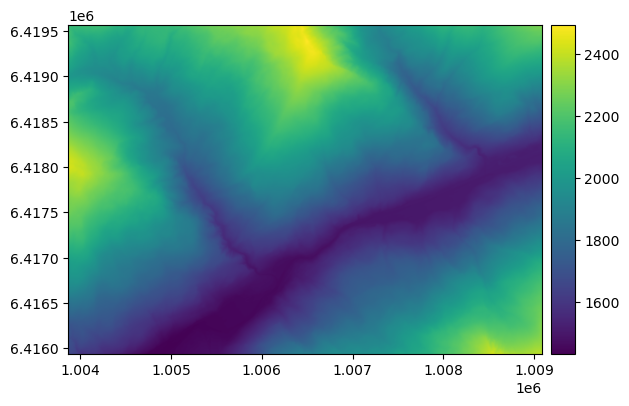

In [15]:
dem_ref.plot()

In [16]:
# Slope mask (remove steep terrain from stable reference)
slope      = xdem.terrain.slope(dem_ref)
slope_mask = (slope.data < 40).filled(False)
del slope

In [17]:
# Moving-area mask (pixels to EXCLUDE from stable reference)
moving_mask = outlines.create_mask(dem_ref)

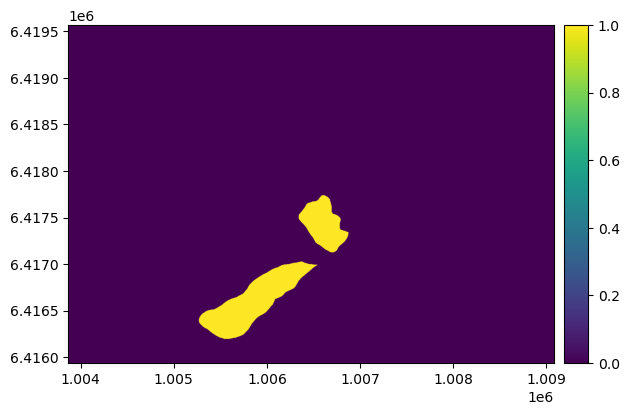

In [18]:
moving_mask.plot()

In [19]:
# Combined inlier mask for ramp/topo fitting:
# stable = not steep AND not moving
inlier_mask = slope_mask & ~moving_mask.data.filled(False)

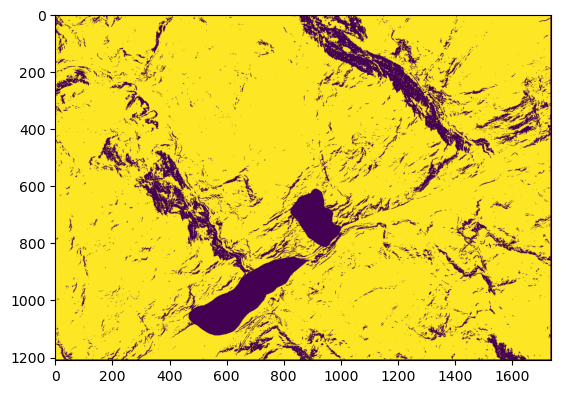

In [22]:
plt.imshow(inlier_mask)

## 8.2. Apply corrections to all pairs

In [5]:
import geomulticorr.corrections as gmc_corr

filter_pipeline = gmc_corr.CCFilter(0.6) + gmc_corr.OutlierFilter((-10, 10))
correction_pipeline = gmc_corr.MedianCentering() + gmc_corr.RampCorrection() + gmc_corr.TopoCorrection(order="quadratic")

In [24]:
results = session.apply_pairs_corrections(
    filter_pipeline=filter_pipeline,
    correction_pipeline=correction_pipeline,
    overwrite=False,      # set True to re-run already-corrected pairs
    save_plot=True,
    dem=dem_ref,              # required by TopoCorrection; omit if not using it
)

[ GMC 🚀 ] : Applying corrections for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' [MedianCentering] (ew valid=1655654, ns valid=1655730)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' [RampCorrection] (ew valid=1655654, ns valid=1655730)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' [TopoCorrection] (ew valid=1655654, ns valid=1655730)
[ GMC 💾 ] : Correction plot saved: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope_corrections_disp.jpg
[ GMC 📄 ] : Saved corrected EW: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F_EW_corr.tif
[ GMC 📄 ] : Saved corrected NS: PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope-F_NS_corr.tif
[ GMC 🚀 ] : Applying corrections for 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope'
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope' [MedianCentering] (ew valid=160984

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope' [MedianCentering] (ew valid=1596989, ns valid=1596922)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope' [RampCorrection] (ew valid=1596989, ns valid=1596922)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope' [TopoCorrection] (ew valid=1596989, ns valid=1596922)
[ GMC 💾 ] : Correction plot saved: PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope_corrections_disp.jpg
[ GMC 📄 ] : Saved corrected EW: PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope-F_EW_corr.tif
[ GMC 📄 ] : Saved corrected NS: PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope-F_NS_corr.tif
[ GMC 🚀 ] : Applying corrections for 'PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope'


...

[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope' [MedianCentering] (ew valid=1426105, ns valid=1427024)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope' [RampCorrection] (ew valid=1426105, ns valid=1427024)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope' [TopoCorrection] (ew valid=1426105, ns valid=1427024)
[ GMC 💾 ] : Correction plot saved: PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope_corrections_disp.jpg
[ GMC 📄 ] : Saved corrected EW: PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope-F_EW_corr.tif
[ GMC 📄 ] : Saved corrected NS: PasDeLours_2024-07-08-planetscope_2023-07-17-planetscope-F_NS_corr.tif
[ GMC 🚀 ] : Applying corrections for 'PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope' [MedianCentering] (ew valid=1411771, ns valid=1411183)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope' [RampCorrection] (ew valid=1411771, ns valid=1411183)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope' [TopoCorrection] (ew valid=1411771, ns valid=1411183)
[ GMC 💾 ] : Correction plot saved: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope_corrections_disp.jpg
[ GMC 📄 ] : Saved corrected EW: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F_EW_corr.tif
[ GMC 📄 ] : Saved corrected NS: PasDeLours_2024-07-08-planetscope_2025-07-16-planetscope-F_NS_corr.tif
[ GMC 🚀 ] : Applying corrections for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope'


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope' [MedianCentering] (ew valid=1467324, ns valid=1466914)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope' [RampCorrection] (ew valid=1467324, ns valid=1466914)
[ GMC 📊 ] : Corrected stats saved for 'PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope' [TopoCorrection] (ew valid=1467324, ns valid=1466914)
[ GMC 💾 ] : Correction plot saved: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope_corrections_disp.jpg
[ GMC 📄 ] : Saved corrected EW: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F_EW_corr.tif
[ GMC 📄 ] : Saved corrected NS: PasDeLours_2025-07-16-planetscope_2024-07-08-planetscope-F_NS_corr.tif
[ GMC ✓ ] : Applied corrections for 20/20 pair(s) (0 skipped).


# 9. TIO inversion

In [3]:
import geomulticorr.inversion as gmc_inv

In [6]:
inv = gmc_inv.TIOInversion(
    session,
    session.get_pairs(),
    inversion_name="PDL_test",
    filter_pipeline=filter_pipeline,          # None to skip
    tio_binaries_dir="/home/cusicand/TIO_install",
)
print(inv)

[ GMC 📋 ] : TIO inversion 'PDL_test' will be stored in: /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/inversion_PDL_test
[ GMC 📋 ] : TIO binaries found: invers_pixel_omp, lect_depl_cumule_lin
TIOInversion(inversion_name='PDL_test', pairs=20, images=11, filter=yes)


In [7]:
inv.prepare(
    weight_mode="temporal",  # "uniform" / "temporal" / "sigmoid" / "parametric"
    cluster="isterre",           # None = local; "isterre" / "gricad" = HPC
    cores=8,
    overwrite=True,
)

[ GMC 📋 ] : TIO ── preparing 'PDL_test' (20 pairs, 11 images)
[ GMC 📋 ] : Creating directory tree → /data/risques/cusicand/GMC_Projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/inversion_PDL_test
[ GMC 📋 ] : Writing 'File_info.rsc'
[ GMC 📋 ] : TIO making pairs (1/20) 2016-08-16 → 2017-07-03
[ GMC 📄 ] : Exported PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope to ENVI binary: 20160816_20170703_EW, 20160816_20170703_NS
[ GMC 📋 ] : TIO making pairs (2/20) 2017-07-03 → 2016-08-16
[ GMC 📄 ] : Exported PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope to ENVI binary: 20170703_20160816_EW, 20170703_20160816_NS
[ GMC 📋 ] : TIO making pairs (3/20) 2017-07-03 → 2017-07-13
[ GMC 📄 ] : Exported PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope to ENVI binary: 20170703_20170713_EW, 20170703_20170713_NS
[ GMC 📋 ] : TIO making pairs (4/20) 2017-07-13 → 2017-07-03
[ GMC 📄 ] : Exported PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope to ENVI binary: 20170713_20170703_EW, 2

In [8]:
# inv.launch(mode="isterre")   # or "hpc" for cluster submission
inv.launch(direction="both", mode="isterre")

[ GMC 📋 ] : TIO ── submitting launch_TIO_inv_EW.sh
[ADMISSION RULE] Modify resource description with type constraints
[ADMISSION RULE] Automatically add the constraint to go on the iste-pro-sarall dedicated nodes.
OAR_JOB_ID=3678156
[ GMC 📋 ] : TIO ── submitting launch_TIO_inv_NS.sh
[ADMISSION RULE] Modify resource description with type constraints
[ADMISSION RULE] Automatically add the constraint to go on the iste-pro-sarall dedicated nodes.
OAR_JOB_ID=3678157


In [9]:
inv.post_process(direction="both", overwrite=True)

[ GMC 📋 ] : post_process ── converting 11 TOT files [EW]
[ GMC 📄 ] :   TOT_20160816.tif
[ GMC 📄 ] :   TOT_20170703.tif
[ GMC 📄 ] :   TOT_20170713.tif
[ GMC 📄 ] :   TOT_20180729.tif
[ GMC 📄 ] :   TOT_20190713.tif
[ GMC 📄 ] :   TOT_20200725.tif
[ GMC 📄 ] :   TOT_20210710.tif
[ GMC 📄 ] :   TOT_20220722.tif
[ GMC 📄 ] :   TOT_20230717.tif
[ GMC 📄 ] :   TOT_20240708.tif
[ GMC 📄 ] :   TOT_20250716.tif
[ GMC 📋 ] : post_process ── converting 11 TOT files [NS]
[ GMC 📄 ] :   TOT_20160816.tif
[ GMC 📄 ] :   TOT_20170703.tif
[ GMC 📄 ] :   TOT_20170713.tif
[ GMC 📄 ] :   TOT_20180729.tif
[ GMC 📄 ] :   TOT_20190713.tif
[ GMC 📄 ] :   TOT_20200725.tif
[ GMC 📄 ] :   TOT_20210710.tif
[ GMC 📄 ] :   TOT_20220722.tif
[ GMC 📄 ] :   TOT_20230717.tif
[ GMC 📄 ] :   TOT_20240708.tif
[ GMC 📄 ] :   TOT_20250716.tif
[ GMC 📋 ] : post_process ── computing magnitude for 11 dates
[ GMC 📄 ] :   magnitude: TOT_20160816.tif
[ GMC 📄 ] :   magnitude: TOT_20170703.tif
[ GMC 📄 ] :   magnitude: TOT_20170713.tif
[ GMC 📄 ] :   mag